# 一次观察的区域构图与记忆检索调试

依据 `docs/algorithm/Alg_onceoptimizer_beta.md`，入口为
`src/nns/memorygraphs/graph_memorypool_onceoptimizer.py`。

用户已完成一次运行并观察到正常分割。本次补充图注与图例，未重新执行构图或调参。
已保存的图片仍保留上次运行结果；重新执行相应绘图单元后，新图例与色条才会显示。
每次构图新建记忆池，`run_step()` 完成整幅图的一次观察；重复调用会追加新的观察实例，
不再循环 50 次眼跳。查询阶段只读记忆。

观察顺序：CNN 输入与有效视野 → 各模态支持/种子/分区 → 区域锚点与采样 →
星型和接触关系 → 几何核验 → 冻结记忆的位置检索。
GposII 尚未实现完整结构约束，参考星型评分单独展示。

In [11]:
from pathlib import Path
import copy
import importlib
import json
import math
import sys
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from PIL import Image, ImageDraw
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src/nns/memorygraphs/graph_memorypool_onceoptimizer.py').is_file())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
import nns.memorygraphs.graph_memorypool_onceoptimizer as memory_module
importlib.reload(memory_module)
from nns.memorygraphs.graph_memorypool_onceoptimizer import (
    MemoryConfig, MultilevelCoordinator, prepare_feature_subspaces,
    check_written_geometry, reference_star_response,
)
from nns.cnns.features import RetinaModel, MultiScaleFeatureBank

DEVICE = torch.device('cpu')
# CPU threads are explicit so runs can be compared. No parameter sweep runs automatically.
torch.set_num_threads(2)
OUTPUT = ROOT / 'results/onceoptimizer'
print('Project:', ROOT)
print('PyTorch:', torch.__version__, 'device:', DEVICE)

Project: /home/p/code/Conscious-linux/Conscious-demo
PyTorch: 2.10.0+cu126 device: cpu


## 1. 输入与配置

默认使用仓库内图片，可以将 `IMAGE_PATH=None` 切换为合成图。
输入缩放后再送入现有 Retina；不改变 CNN 参数。首轮只启用梯度与 RGB，
额外模态通过 `ENABLE_ADVANCED` 开启。所有距离参数均使用特征图像素单位。

`PARAMS` 只覆盖本次配置。降低 `tau_grad_str` 等已有门控会同时影响可写位置与检索，
应单独记录；以下没有预先宣称任何配置最优。

### 图片说明（从左到右）

| 图片 | 含义与颜色 |
| --- | --- |
| CNN view | 预处理后的 RGB 图，后续所有点与边均使用这张图的像素坐标。 |
| Valid input mask | 白色为有效输入，黑色为填充或无效位置；并非物体分割结果。 |
| Gradient strength | 梯度强度，颜色越亮表示变化越强；色条给出实际数值，不是概率。 |

所有图的坐标均为 `(x, y)`：向右为 x 增大，向下为 y 增大。


Original H,W: (192, 256) feature shape: (1, 3, 256, 256)
Modalities: {0: (1, 4, 256, 256), 1: (1, 3, 256, 256)}


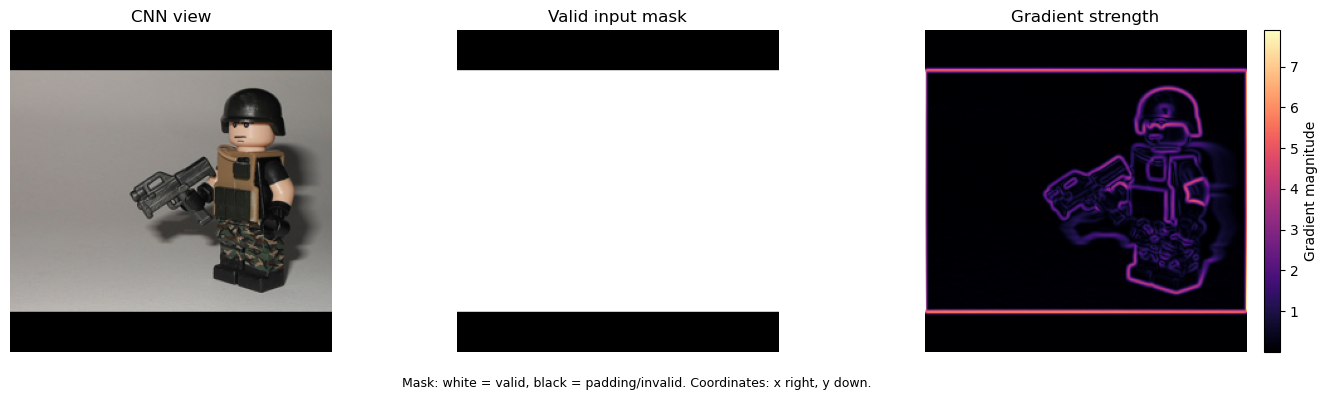

In [12]:
# IMAGE_PATH = ROOT / 'src/picture/OIP-C.jpg'  # None: synthetic image
IMAGE_PATH = '/home/p/code/ILSVRC/Data/DET/train/ILSVRC2014_train_0006/ILSVRC2014_train_00060030.JPEG'
VIEW_SIZE = 256
ENABLE_ADVANCED = False
ADVANCED_SCALES = [1, 2, 4]
PARAMS = {
    'once_node_reuse_mode': 'sample_instance',
    'once_samples_per_region': 64,
    'once_region_budget': 256,
    'once_write_local_contacts': False,
}


def make_synthetic(size):
    image = Image.new('RGB', (size, size), (235, 235, 235))
    draw = ImageDraw.Draw(image)
    def box(x0, y0, x1, y1):
        return tuple(int(v * size) for v in (x0, y0, x1, y1))
    draw.rectangle(box(.06, .08, .37, .40), fill=(60, 120, 200))
    draw.rectangle(box(.62, .10, .88, .34), fill=(60, 120, 200))
    draw.ellipse(box(.10, .54, .44, .89), fill=(200, 100, 60))
    draw.ellipse(box(.20, .64, .34, .79), fill=(235, 235, 235))
    draw.arc(box(.52, .46, .94, .90), start=5, end=285, fill=(30, 30, 30), width=3)
    return image


if IMAGE_PATH is None:
    pil_image = make_synthetic(VIEW_SIZE)
else:
    pil_image = Image.open(IMAGE_PATH).convert('RGB')
    pil_image.thumbnail((VIEW_SIZE, VIEW_SIZE))
image_tensor = torch.from_numpy(np.asarray(pil_image).copy()).permute(2, 0, 1)[None].float() / 255.
original_hw = tuple(image_tensor.shape[-2:])
retina = RetinaModel(cropped_size=VIEW_SIZE, output_size=VIEW_SIZE,
                    edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.).eval().to(DEVICE)
feature_bank = MultiScaleFeatureBank(ADVANCED_SCALES).eval().to(DEVICE) if ENABLE_ADVANCED else None


@torch.no_grad()
def encode_image(tensor, pixel_valid=None):
    tensor = tensor.to(DEVICE)
    _, grad, _, _, _, cropped = retina(tensor, center_x=-1, center_y=-1)
    # Process a mask through the exact same cropping transform, including odd dimensions.
    source_mask = torch.ones_like(tensor[:, :1]) if pixel_valid is None else pixel_valid.to(DEVICE)
    valid = retina.preprocess(source_mask, -1, -1)[0, 0] > 0.999
    named = {'grad': grad, 'rgb': cropped}
    if feature_bank is not None:
        curvature, aspect, orientation = feature_bank(cropped, precomputed_derivs={'grad': grad})
        named.update(curvature=curvature, aspect=aspect, orientation=orientation)
    return named, cropped, valid


features, image_view, valid_mask = encode_image(image_tensor)


def make_config(overrides=None):
    cfg = MemoryConfig()
    # Copy mutable class defaults before any experimental edits.
    for name in dir(cfg):
        if not name.startswith('_') and isinstance(getattr(cfg, name), (dict, list)):
            setattr(cfg, name, copy.deepcopy(getattr(cfg, name)))
    cfg.device = DEVICE
    cfg.H, cfg.W = image_view.shape[-2:]
    for key, value in {**PARAMS, **(overrides or {})}.items():
        if not hasattr(cfg, key):
            raise ValueError('Unknown parameter: ' + key)
        setattr(cfg, key, copy.deepcopy(value))
    return cfg


cfg = make_config()
inputs = prepare_feature_subspaces(features, cfg)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image_view[0].permute(1, 2, 0).cpu().clamp(0, 1)); axes[0].set_title('CNN view')
axes[1].imshow(valid_mask.cpu(), cmap='gray', vmin=0, vmax=1); axes[1].set_title('Valid input mask')
strength_plot = axes[2].imshow(inputs[0][0, 0].cpu(), cmap='magma'); axes[2].set_title('Gradient strength')
for ax in axes:
    ax.axis('off')
fig.colorbar(strength_plot, ax=axes[2], fraction=.046, pad=.04, label='Gradient magnitude')
fig.text(.5, .02, 'Mask: white = valid, black = padding/invalid. Coordinates: x right, y down.', ha='center', fontsize=9)
plt.tight_layout(rect=(0, .07, 1, 1))
print('Original H,W:', original_hw, 'feature shape:', tuple(image_view.shape))
print('Modalities:', {m: tuple(x.shape) for m, x in inputs.items()})

## 2. 一次观察

以下单元每次执行都创建独立记忆。返回的 `report` 包含支持图、标签、区域、采样和边的真值坐标。
节点激活状态保持默认；Gpos 查询通过显式节点列表进行，避免与神经元不应期混淆。

In [37]:
coordinator = MultilevelCoordinator(cfg)
start = time.perf_counter()
report = coordinator.controller.run_step(
    inputs, coordinator.gmem_i, coordinator.gmem_ii, coordinator.gmem_iii, coordinator.gpos,
    valid_mask=valid_mask,
)
coordinator.last_report = report
print('Observation:', coordinator.controller.current_step, 'elapsed:', time.perf_counter() - start)
display(report.summary())
print('GmemI / GmemII / GmemIII:', len(coordinator.gmem_i.nodes),
      len(coordinator.gmem_ii.semantic_nodes), len(coordinator.gmem_iii.entity_nodes))
print(len(report.regions))
print('Example rejections:')
display(report.rejection_examples[:12])

Observation: 1 elapsed: 1.3350049259606749


{'build_id': 1,
 'shape': (256, 256),
 'regions': 207,
 'sample_instances': 1671,
 'referenced_nodes': 1671,
 'region_containers': 207,
 'contact_containers': 860,
 'completed_regions': 131,
 'truncated_regions': 1,
 'edge_observations': 2324,
 'rejected': {'nonfinite_pixels': 0,
  'local_similarity': 20988,
  'direction_conflict': 115,
  'junction_connections': 28,
  'small_region': 7247,
  'region_budget': 5,
  'surface_barrier': 16550,
  'region_range': 2695,
  'contact_pair_budget': 24,
  'contact_sample_budget': 3,
  'unwritten_contact': 3},
 'timings': {'supports': 0.10041469801217318,
  'regions': 0.6976098460145295,
  'contacts': 0.21978568204212934,
  'sampling': 0.2449800000176765,
  'writing': 0.07106845098314807,
  'total': 1.3343614190234803},
 'warnings': []}

GmemI / GmemII / GmemIII: 1671 1067 0
207
Example rejections:


[{'reason': 'small_region', 'modality': 0, 'size': 3},
 {'reason': 'small_region', 'modality': 0, 'size': 3},
 {'reason': 'small_region', 'modality': 0, 'size': 3},
 {'reason': 'small_region', 'modality': 0, 'size': 3},
 {'reason': 'small_region', 'modality': 0, 'size': 3},
 {'reason': 'small_region', 'modality': 0, 'size': 2},
 {'reason': 'small_region', 'modality': 0, 'size': 2},
 {'reason': 'small_region', 'modality': 0, 'size': 2},
 {'reason': 'small_region', 'modality': 0, 'size': 2},
 {'reason': 'small_region', 'modality': 0, 'size': 1},
 {'reason': 'small_region', 'modality': 0, 'size': 2},
 {'reason': 'small_region', 'modality': 0, 'size': 1}]

## 3. 支持、种子与区域分割

每个模态单独输出一行四张图。模态编号：0=梯度/边缘，1=RGB，2=曲率，3=长宽比，4=方向。

| 图片（从左到右） | 含义 | 颜色与叠加标记 |
| --- | --- | --- |
| Reliability | 用于分割的支持可靠度，不是 Gpos 相似度，也不是识别概率；高可靠度不一定通过写入门控。 | 色条范围 0～1，紫色低、黄色高。 |
| Writable gate | 能通过现有描述子门控的位置。 | 白色=可写，黑色=不可写。 |
| Support / seeds / events | 用于局部连通分割的支持位置，可能经过强度筛选和边缘细化，因而比可写集合更小。 | 白色=支持，黑色=非支持；**红色圆点=初始种子**；**青色圆点=事件候选**。 |
| Regions / anchors | 保留的区域及其实际采样锚点。 | 伪彩色=区域标签；黑色=未保留区域；**黄色 ×=区域锚点**。 |

事件候选包括方向不可靠点或分支事件，不应一概解释为已确认的角点/交叉点。
初始种子只用于分区标记；区域锚点是在分割后选择的，二者可以不同。构图器补选的区域种子可在 `r.seeds` 查看，第三张图只画 `support.seeds` 中的初始种子。

区域色彩只帮助区分标签，不表示原始颜色、语义类别或相似度。`tab20` 颜色有限，**同色不保证属于同一区域**，不同模态的颜色也不对应。黑色可能来自门控、小区域过滤或预算，详见 `report.rejected`。不同模态的区域允许空间重叠。


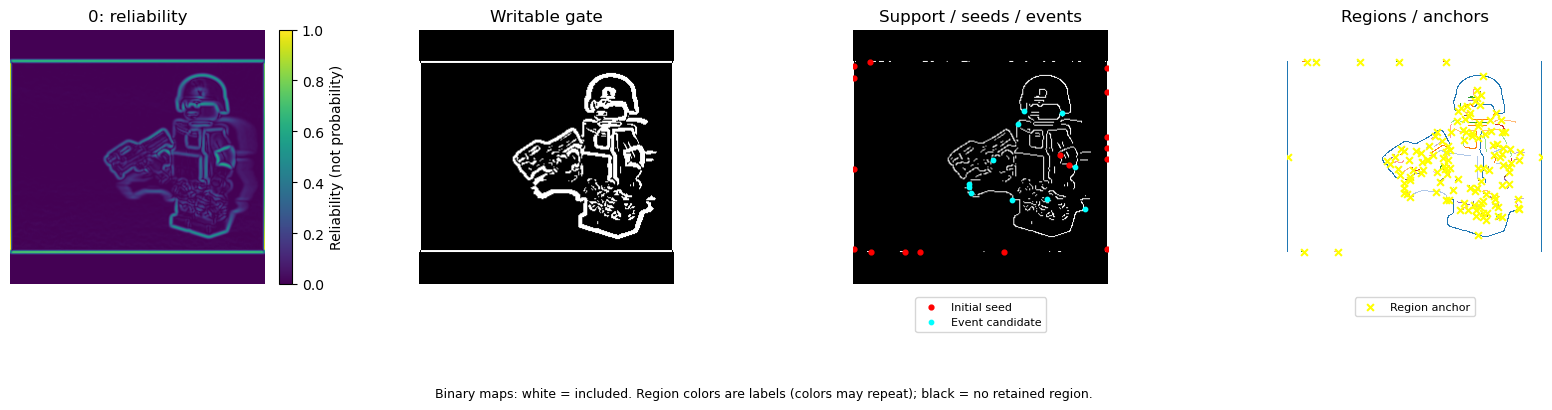

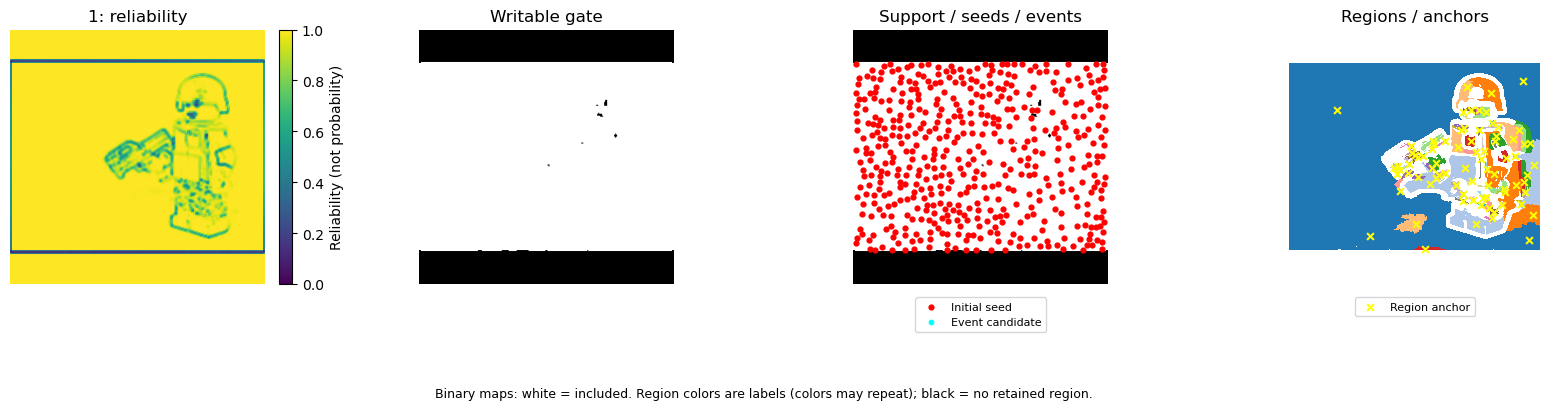

In [14]:
for mid, support in report.supports.items():
    labels = report.labels[mid]
    fig, axes = plt.subplots(1, 4, figsize=(17, 4))
    reliability_plot = axes[0].imshow(support.quality, cmap='viridis', vmin=0, vmax=1)
    axes[0].set_title(f'{mid}: reliability')
    axes[1].imshow(support.writable, cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Writable gate')
    axes[2].imshow(support.support, cmap='gray', vmin=0, vmax=1)
    axes[2].set_title('Support / seeds / events')
    if support.seeds:
        axes[2].scatter(np.asarray(support.seeds) % cfg.W, np.asarray(support.seeds) // cfg.W, s=12, c='red', label='Initial seed')
    ey, ex = np.nonzero(support.events)
    axes[2].scatter(ex, ey, s=10, c='cyan', label='Event candidate')
    axes[3].imshow(np.ma.masked_less(labels, 0), cmap='tab20', interpolation='nearest')
    axes[3].set_facecolor('black'); axes[3].set_title('Regions / anchors')
    for r in report.regions:
        if r.modality_id == mid and r.anchor is not None:
            axes[3].scatter(r.anchor % cfg.W, r.anchor // cfg.W, c='yellow', marker='x', s=24, label='Region anchor')
    fig.colorbar(reliability_plot, ax=axes[0], fraction=.046, pad=.04, label='Reliability (not probability)')
    for ax in axes[2:]:
        handles, names = ax.get_legend_handles_labels()
        unique = dict(zip(names, handles))
        if unique:
            ax.legend(unique.values(), unique.keys(), loc='upper center', bbox_to_anchor=(.5, -.03), fontsize=8)
    for ax in axes:
        ax.axis('off')
    fig.text(.5, .02, 'Binary maps: white = included. Region colors are labels (colors may repeat); black = no retained region.', ha='center', fontsize=9)
    plt.tight_layout(rect=(0, .17, 1, 1))
    plt.show()

## 4. 单区域检查

修改 `REGION_INDEX` 查看其他区域。星型锚点一定是实际采样位置；
`coverage_error` 使用区域邻接图的路径距离，`curve_error` 是有序曲线的折线误差。
无法可靠排序的线域会标记 `curve_order_unresolved`，不会冒充完成。

### 图片与标记说明

| 图片/标记 | 含义 |
| --- | --- |
| 左图 RGB 底图 | 当前区域在输入图中的位置。 |
| 左图红橙色半透明覆盖 | 当前选中区域的支持范围；不是该区域的原始颜色。 |
| 右图二值掩码 | 白色=当前区域，黑色=区域外；孔洞也显示为黑色。 |
| 两图的青色圆点 | 最终选中的采样位置；有可写原型后用于注册/引用 GmemI 节点。 |
| 两图的红色 ★ | 当前区域的星型锚点；也是采样位置之一，可能遮住同位置的青色圆点。 |

有锚点标记并不保证区域已经写入：若预算不足，仍可能有候选锚点而 `semantic_id=None`；实际状态查看下方字段。
`coverage_error` 的单位为特征图像素路径距离；`curve_error` 仅对线域有意义，二维区域的默认值不代表做过曲线拟合。


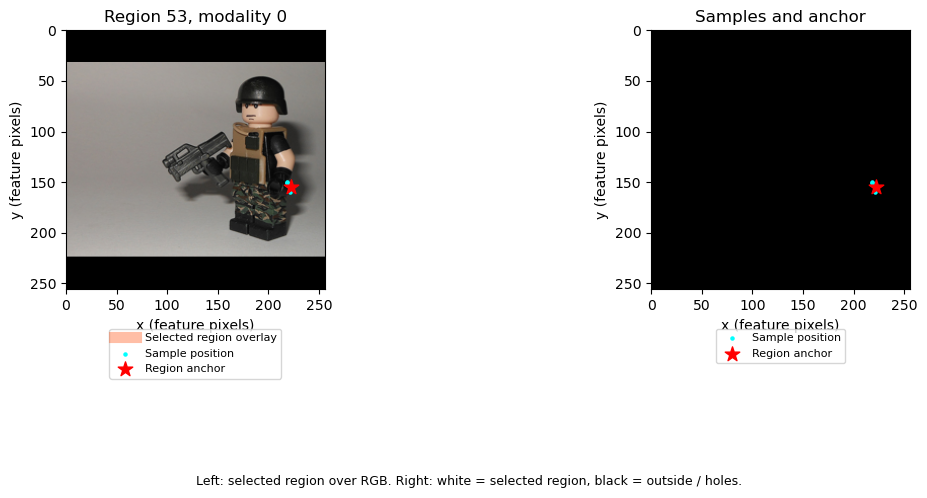

{'region': 53,
 'modality': 0,
 'support_dim': 1,
 'pixels': 14,
 'samples': 6,
 'semantic_id': 53,
 'completed': False,
 'coverage_error': 2.414213562373095,
 'curve_error': inf,
 'budget_truncated': False,
 'view_truncated': False,
 'closed': False,
 'reasons': ['curve_order_unresolved', 'sampling_target_unmet']}

In [39]:
REGION_INDEX = 53


def show_region(index):
    if not report.regions:
        print('No retained regions; inspect gates, rejections and budgets first.')
        return
    r = report.regions[min(max(0, index), len(report.regions) - 1)]
    mask = report.labels[r.modality_id] == r.region_id
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].imshow(image_view[0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[0].imshow(np.ma.masked_where(~mask, mask), alpha=.35, cmap='autumn')
    axes[1].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[0].plot([], [], color='orangered', linewidth=8, alpha=.35, label='Selected region overlay')
    for ax in axes:
        if r.samples:
            samples = np.asarray(r.samples)
            ax.scatter(samples % cfg.W, samples // cfg.W, s=5, c='cyan', label='Sample position')
        if r.anchor is not None:
            ax.scatter(r.anchor % cfg.W, r.anchor // cfg.W, marker='*', s=120, c='red', label='Region anchor')
        ax.set_xlim(0, cfg.W); ax.set_ylim(cfg.H, 0)
        ax.set_xlabel('x (feature pixels)'); ax.set_ylabel('y (feature pixels)')
        handles, names = ax.get_legend_handles_labels()
        if handles:
            ax.legend(handles, names, loc='upper center', bbox_to_anchor=(.5, -.13), fontsize=8)
    axes[0].set_title(f'Region {r.region_id}, modality {r.modality_id}')
    axes[1].set_title('Samples and anchor')
    fig.text(.5, .02, 'Left: selected region over RGB. Right: white = selected region, black = outside / holes.', ha='center', fontsize=9)
    plt.tight_layout(rect=(0, .17, 1, 1)); plt.show()
    display({'region': r.region_id, 'modality': r.modality_id, 'support_dim': r.support_dim,
             'pixels': len(r.pixels), 'samples': len(r.samples), 'semantic_id': r.semantic_id,
             'completed': r.completed, 'coverage_error': r.coverage_error, 'curve_error': r.curve_error,
             'budget_truncated': r.budget_truncated, 'view_truncated': r.view_truncated,
             'closed': r.closed, 'reasons': r.reasons})


show_region(REGION_INDEX)

## 5. 星型与跨区域接触

左图显示区域星型，右图显示跨区接触与可选曲线局部边。所有端点均属于 GmemI；
区域星型与接触关系归不同 GmemII 容器。为可读性，绘图可截断，实际存储数量另行打印。

### 图片与线条说明

- **左图青色线段**：区域星型边，将锚点与该区域的外围采样点连接。线段代表存储的相对位置关系，不是图像轮廓或眼跳轨迹。
- **右图红色线段**：跨区域接触边，以及启用 `once_write_local_contacts` 后的曲线局部边。每条关系由独立接触容器组织。
- 两图底图均为输入 RGB。线段不画箭头，不能从外观判断边方向；方向查看 `source_xy → target_xy`。共位连接投影为零长度，可能不可见。
- 标题中 `edges` 为该类边的总数，`showing` 为实际绘制数；超过 `MAX_DRAW_EDGES` 的部分仍在记忆中。


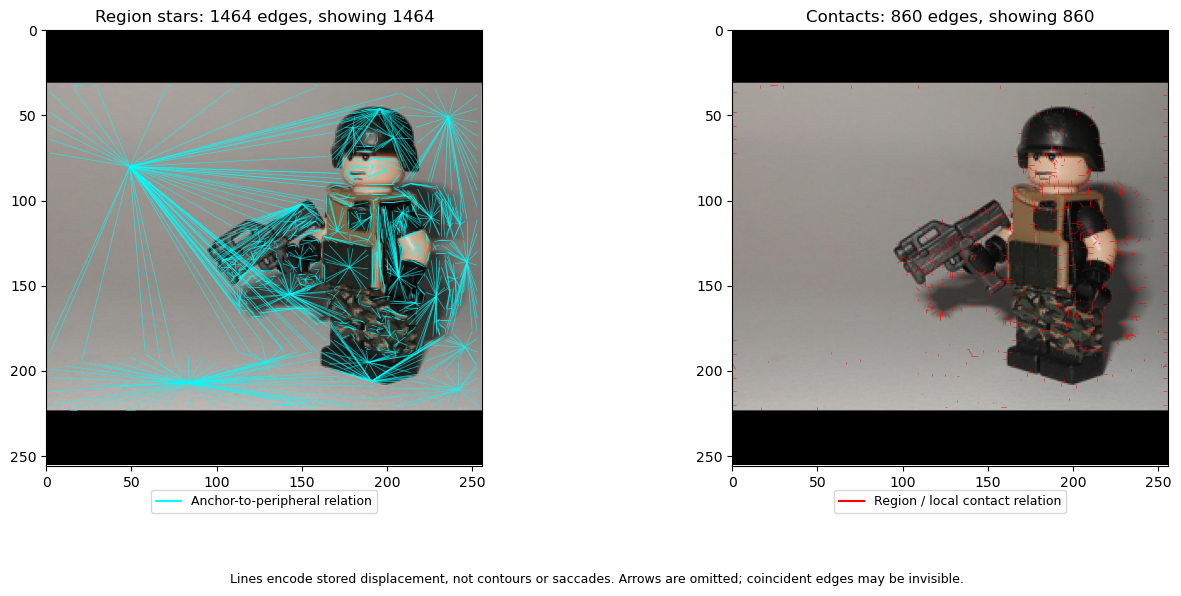

Registered sample instances: 1671 referenced node ids: 1671
Region containers: 207 contact containers: 860


In [ ]:
MAX_DRAW_EDGES = 2000
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax in axes:
    ax.imshow(image_view[0].permute(1, 2, 0).cpu().clamp(0, 1))
    ax.set_xlim(0, cfg.W); ax.set_ylim(cfg.H, 0)
for ax, is_star, color in zip(axes, (True, False), ('cyan', 'red')):
    selected = [e for e in report.edge_observations if (e['kind'] == 'region_star') == is_star]
    segments = [(e['source_xy'], e['target_xy']) for e in selected[:MAX_DRAW_EDGES]]
    if segments:
        ax.add_collection(LineCollection(segments, colors=color, linewidths=.6, alpha=.6))
    ax.plot([], [], color=color, label='Anchor-to-peripheral relation' if is_star else 'Region / local contact relation')
    ax.legend(loc='upper center', bbox_to_anchor=(.5, -.04), fontsize=9)
    ax.set_title(f'{"Region stars" if is_star else "Contacts"}: {len(selected)} edges, showing {len(segments)}')
fig.text(.5, .02, 'Lines encode stored displacement, not contours or saccades. Arrows are omitted; coincident edges may be invisible.', ha='center', fontsize=9)
plt.tight_layout(rect=(0, .11, 1, 1)); plt.show()
print('Registered sample instances:', len(report.sample_nodes), 'referenced node ids:', len(report.node_ids))
print('Region containers:', len(report.region_semantic_ids), 'contact containers:', len(report.contact_semantic_ids))

## 6. 写入几何核验

该单元使用构图真值，仅检查写入是否正确，不属于位置检索实验。
实例模式下误差应接近浮点误差；共位边使用对数距离下限，显示其小量编码误差。
原型复用对照中，边合并可能改变几何，应查看最大误差和自环比例。

In [17]:
geometry = check_written_geometry(report, coordinator.gmem_ii)
errors = np.asarray([row['position_error'] for row in geometry], dtype=float)
print('Max position error:', errors.max() if len(errors) else None)
print('Coincident edges:', sum(row['coincident'] for row in geometry))
print('Collapsed instances:', sum(row['collapsed_instances'] for row in geometry))
print('Merged edges:', sum(row['merged_count'] > 1 for row in geometry))
print('Worst rows:')
display(sorted(geometry, key=lambda row: row['position_error'], reverse=True)[:10])

Max position error: 7.105427357601002e-14
Coincident edges: 0
Collapsed instances: 0
Merged edges: 0
Worst rows:


[{'semantic_id': 128,
  'edge_id': 663,
  'kind': 'region_star',
  'source_id': 810,
  'target_id': 1541,
  'source_xy': (49, 80),
  'target_xy': (147, 188),
  'rho': 4.982479437312114,
  'theta': 0.8339037756378318,
  'coincident': False,
  'collapsed_instances': False,
  'decoded_delta': (97.99999999999996, 107.99999999999994),
  'position_error': 7.105427357601002e-14,
  'merged_count': 1},
 {'semantic_id': 128,
  'edge_id': 664,
  'kind': 'region_star',
  'source_id': 810,
  'target_id': 1542,
  'source_xy': (49, 80),
  'target_xy': (156, 188),
  'rho': 5.024075254388344,
  'theta': 0.7900492926485576,
  'coincident': False,
  'collapsed_instances': False,
  'decoded_delta': (106.99999999999996, 107.99999999999994),
  'position_error': 7.105427357601002e-14,
  'merged_count': 1},
 {'semantic_id': 128,
  'edge_id': 668,
  'kind': 'region_star',
  'source_id': 810,
  'target_id': 1560,
  'source_xy': (49, 80),
  'target_xy': (2, 190),
  'rho': 4.784321994453368,
  'theta': 1.97459041

## 7. 冻结记忆的 GposI 与结构检索

仅查询一个区域的节点，避免同时保存所有节点的全图响应。测试包含原图、平移图、
左右半图交换的干扰图。半图交换不是对每个区域都有效的负例，应选择确实被改变的结构，
并进一步用“特征相同但相对排布不同”的人工样例检验。

`GposII (existing)` 是当前真实接口；`Reference star` 是只读固定尺度/方向的参考判据，
只使用响应与存储边。它没有重复实例的一对一分配约束，结果不能代表 GposII 已完成。

### 检索图片与标记说明（每组从左到右）

| 图片 | 含义与标记 |
| --- | --- |
| original / translated / half_swap | 本次查询 RGB 图，分别为原图、平移图、左右半图交换后的图。 |
| GposI anchor response | 锚点特征原型在查询图中的位置响应。颜色越亮，特征越匹配；可有多个峰，不代表区域结构匹配成功。 |
| Reference star (not GposII) | 由锚点和存储的星型边计算的参考结构响应；不是现有 GposII 输出。颜色越亮，参考评分越高。 |
| 第三张图的青色 × | 按已知平移计算出的**期望锚点位置**，用于误差核验；不是算法预测点。half_swap 没有定义该真值，因此不画。 |

预测峰坐标在下方 `reference_peak.point` 中，当前图片未另外标出。
响应已包含模态权重，**不是校准概率**；各图色条按各自数据取范围，比较强弱应读数值，不能只比较颜色。
现有 GposII 的结果保留在 `existing_gposII` 字段中，不以参考响应图代替。


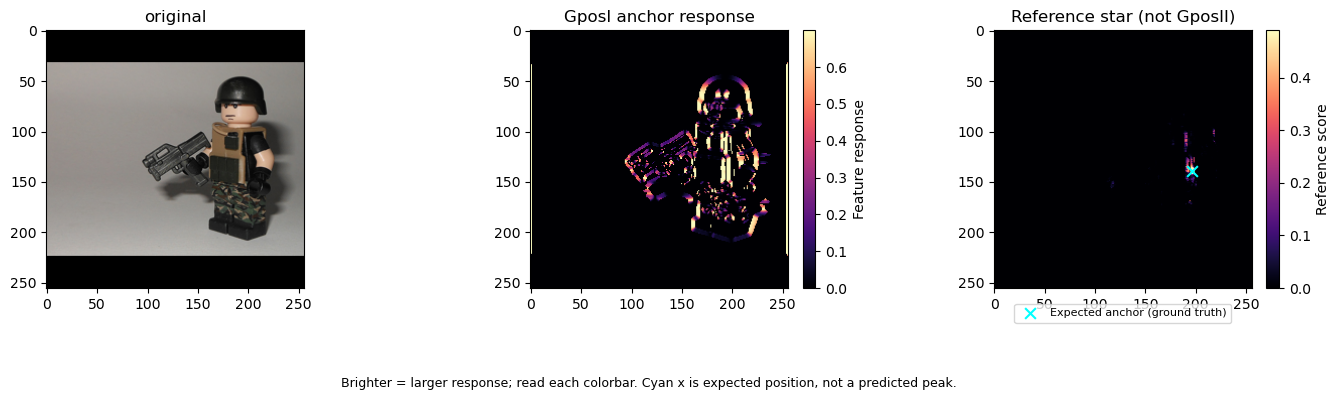

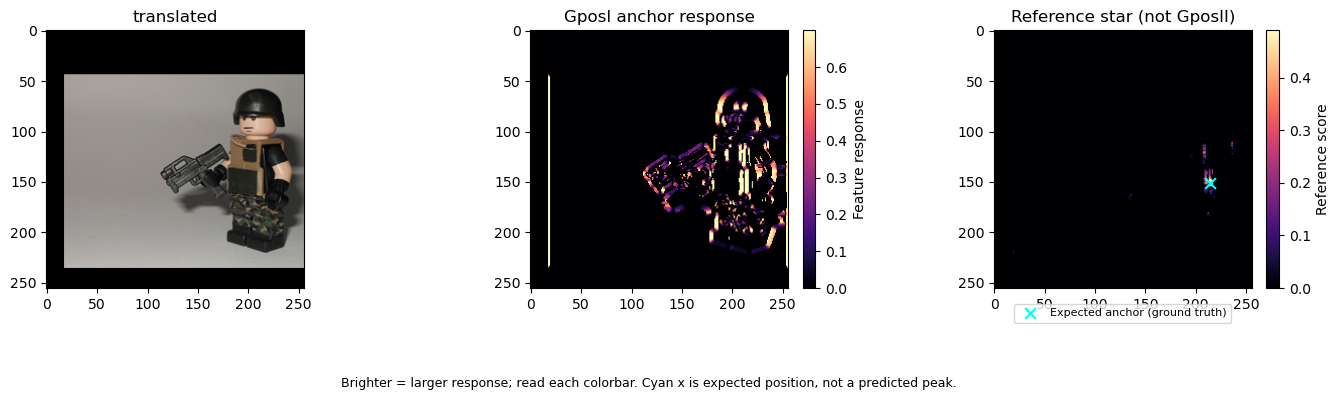

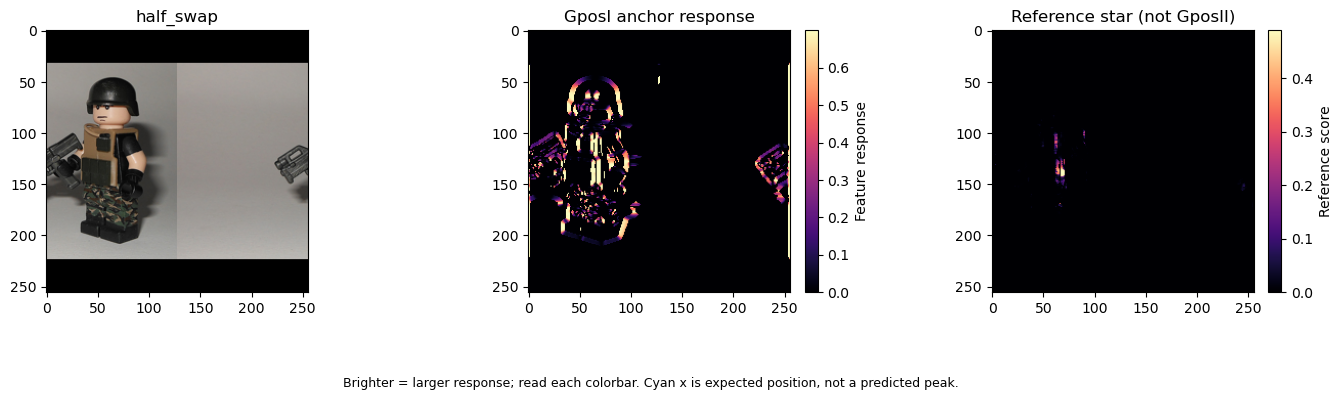

Memory counts before / after read-only query: (1671, 1067, 1) (1671, 1067, 1)


[{'case': 'original',
  'semantic_id': 5,
  'reference_peak': {'point': (196, 139), 'score': 0.4899996817111969},
  'expected_anchor': (196, 139),
  'anchor_error': 0.0,
  'existing_gposII': {'x': 197,
   'y': 133,
   's_star': 0.3795571881830896,
   'theta_star': 2.552544031041707,
   'score': 11.836946487426758}},
 {'case': 'translated',
  'semantic_id': 5,
  'reference_peak': {'point': (214, 151), 'score': 0.4899996817111969},
  'expected_anchor': (214, 151),
  'anchor_error': 0.0,
  'existing_gposII': {'x': 215,
   'y': 145,
   's_star': 0.36787944117144233,
   'theta_star': 2.5034566458293663,
   'score': 11.836941719055176}},
 {'case': 'half_swap',
  'semantic_id': 5,
  'reference_peak': {'point': (68, 139), 'score': 0.4899996817111969},
  'expected_anchor': None,
  'anchor_error': None,
  'existing_gposII': {'x': 69,
   'y': 133,
   's_star': 0.3795571881830896,
   'theta_star': 2.552544031041707,
   'score': 11.83694839477539}}]

In [34]:
QUERY_REGION_INDEX = 5
SHIFT_XY = (18, 12)
REFERENCE_TOLERANCE = 1


def shifted(tensor, dx, dy, fill=0.):
    out = torch.full_like(tensor, fill)
    h, w = tensor.shape[-2:]
    sx0, sx1 = max(0, -dx), min(w, w - dx)
    sy0, sy1 = max(0, -dy), min(h, h - dy)
    if sx1 > sx0 and sy1 > sy0:
        out[..., sy0 + dy:sy1 + dy, sx0 + dx:sx1 + dx] = tensor[..., sy0:sy1, sx0:sx1]
    return out


def peak_info(response):
    if response is None or not response.numel():
        return {'point': None, 'score': None}
    value = response[0, 0]
    idx = int(value.argmax().item())
    return {'point': (idx % value.shape[1], idx // value.shape[1]), 'score': float(value.max().item())}


query_results = []
written_regions = [r for r in report.regions if r.semantic_id is not None]
if not written_regions:
    print('No written regions to query.')
else:
    query_region = written_regions[min(max(0, QUERY_REGION_INDEX), len(written_regions) - 1)]
    sem = coordinator.gmem_ii.semantic_nodes[query_region.semantic_id]
    ids = sorted(sem.related_node_ids())
    source = image_view.detach().clone()
    dx, dy = SHIFT_XY
    source_valid = valid_mask[None, None].float()
    split = cfg.W // 2
    permutation = torch.cat((torch.arange(split, cfg.W), torch.arange(split)))
    query_cases = {
        'original': (source, source_valid, (0, 0)),
        'translated': (shifted(source, dx, dy), shifted(source_valid, dx, dy), (dx, dy)),
        'half_swap': (source[..., permutation], source_valid[..., permutation], None),
    }
    before_counts = (len(coordinator.gmem_i.nodes), len(coordinator.gmem_ii.semantic_nodes),
                     coordinator.controller.current_step)
    for name, (pixels, mask, translation) in query_cases.items():
        query_features, query_view, query_valid = encode_image(pixels, mask)
        maps = coordinator.query_l1(query_features, ids, valid_mask=query_valid)
        reference = reference_star_response(maps, sem, REFERENCE_TOLERANCE)
        existing = coordinator.gpos.l2_structure_synthesis(maps, sem)
        peak = peak_info(reference)
        expected = None if translation is None else (
            query_region.anchor % cfg.W + translation[0], query_region.anchor // cfg.W + translation[1])
        expected_visible = (expected is not None and 0 <= expected[0] < cfg.W and 0 <= expected[1] < cfg.H)
        error = math.dist(peak['point'], expected) if peak['point'] is not None and expected_visible else None
        query_results.append({'case': name, 'semantic_id': sem.node_id,
                              'reference_peak': peak, 'expected_anchor': expected,
                              'anchor_error': error, 'existing_gposII': existing})
        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(query_view[0].permute(1, 2, 0).cpu().clamp(0, 1)); axes[0].set_title(name)
        anchor_map = maps.get(sem.anchor_id)
        if anchor_map is not None:
            anchor_plot = axes[1].imshow(anchor_map[0, 0].cpu(), cmap='magma')
            fig.colorbar(anchor_plot, ax=axes[1], fraction=.046, pad=.04, label='Feature response')
        axes[1].set_title('GposI anchor response')
        if reference is not None:
            reference_plot = axes[2].imshow(reference[0, 0].cpu(), cmap='magma')
            fig.colorbar(reference_plot, ax=axes[2], fraction=.046, pad=.04, label='Reference score')
        axes[2].set_title('Reference star (not GposII)')
        if expected_visible:
            axes[2].scatter(*expected, marker='x', c='cyan', s=60, label='Expected anchor (ground truth)')
            axes[2].legend(loc='upper center', bbox_to_anchor=(.5, -.04), fontsize=8)
        fig.text(.5, .02, 'Brighter = larger response; read each colorbar. Cyan x is expected position, not a predicted peak.', ha='center', fontsize=9)
        plt.tight_layout(rect=(0, .16, 1, 1)); plt.show()
    after_counts = (len(coordinator.gmem_i.nodes), len(coordinator.gmem_ii.semantic_nodes),
                    coordinator.controller.current_step)
    print('Memory counts before / after read-only query:', before_counts, after_counts)
    display(query_results)

## 8. 可选参数对照

默认关闭。启用后每组重新构建全部记忆，不使用前一组的图或激活状态。
先固定分割，仅比较采样预算与实例/原型策略；不要把增加节点数量直接当作效果更好。

In [19]:
RUN_COMPARISONS = False
COMPARISONS = {
    'instance_baseline': {},
    'denser_samples': {'once_samples_per_region': 128, 'once_surface_cover_radius': 8.},
    'prototype_reuse': {'once_node_reuse_mode': 'prototype'},
}
comparison_rows = []
if RUN_COMPARISONS:
    for name, overrides in COMPARISONS.items():
        trial_cfg = make_config(overrides)
        trial = MultilevelCoordinator(trial_cfg)
        trial_report = trial.handle_new_view(inputs, valid_mask=valid_mask)
        rows = check_written_geometry(trial_report, trial.gmem_ii)
        comparison_rows.append({'name': name, 'overrides': overrides,
                                **trial_report.summary(),
                                'max_geometry_error': max((r['position_error'] for r in rows), default=0.),
                                'collapsed_edges': sum(r['collapsed_instances'] for r in rows)})
    display(comparison_rows)
else:
    print('Parameter comparisons disabled.')

Parameter comparisons disabled.


## 9. 保存结果

手动设置 `SAVE_RESULTS=True` 后保存摘要、配置、区域与节点映射、边坐标、检索结果和标签矩阵。
过程掩码只用于诊断，后续查询不得读取这些真值。Notebook 不自动覆盖已有结果目录，
每次保存生成独立时间戳目录。Notebook 内已有输出不会因本次图注修改而自动重绘。

In [20]:
SAVE_RESULTS = False


def json_ready(value):
    if isinstance(value, dict):
        return {str(k): json_ready(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_ready(value.tolist())
    if isinstance(value, np.generic):
        return json_ready(value.item())
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


if SAVE_RESULTS:
    from datetime import datetime
    destination = OUTPUT / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    destination.mkdir(parents=True, exist_ok=False)
    region_rows = [{'region_id': r.region_id, 'modality': r.modality_id, 'support_dim': r.support_dim,
                    'anchor': r.anchor, 'samples': r.samples, 'semantic_id': r.semantic_id,
                    'coverage_error': r.coverage_error, 'curve_error': r.curve_error,
                    'completed': r.completed, 'budget_truncated': r.budget_truncated,
                    'view_truncated': r.view_truncated, 'closed': r.closed, 'reasons': r.reasons}
                   for r in report.regions]
    payload = {'summary': report.summary(), 'config': report.config,
               'input': str(IMAGE_PATH) if IMAGE_PATH is not None else 'synthetic',
               'view_size': VIEW_SIZE, 'original_hw': original_hw,
               'advanced_scales': ADVANCED_SCALES if ENABLE_ADVANCED else [],
               'regions': region_rows,
               'sample_nodes': [{'modality': m, 'pixel': p, 'node_id': nid}
                                for (m, p), nid in report.sample_nodes.items()],
               'edges': geometry, 'queries': query_results, 'comparisons': comparison_rows,
               'rejection_examples': report.rejection_examples}
    (destination / 'report.json').write_text(json.dumps(json_ready(payload), ensure_ascii=False,
                                                     indent=2, allow_nan=False))
    arrays = {'valid_mask': report.valid_mask}
    arrays.update({f'labels_{m}': value for m, value in report.labels.items()})
    arrays.update({f'support_{m}': value.support for m, value in report.supports.items()})
    np.savez_compressed(destination / 'maps.npz', **arrays)
    # Persist exact pools separately from diagnostic coordinate truth.
    torch.save({'gmem_i': coordinator.gmem_i, 'gmem_ii': coordinator.gmem_ii,
                'gmem_iii': coordinator.gmem_iii}, destination / 'memory.pt')
    print('Saved:', destination)
else:
    print('Saving disabled.')

Saving disabled.
